# Simple drift-classification demo for `ParaRNN`

This notebook uses a deliberately simple long-sequence task:

$$
y = \mathbf{1}\left\{\frac{1}{T}\sum_{t=1}^{T} x_{t,0} > 0\right\}
$$

Each sequence has a weak positive or negative drift in channel `0`; the other channels are pure noise. The model must integrate weak evidence over time.

Models compared:

1. `torch.nn.RNN`
2. `ParaRNN` sequential
3. `ParaRNN` full-DEER with torch dense scan
4. `ParaRNN` quasi-DEER with torch diagonal scan
5. `ParaRNN` quasi-DEER with `accelerated_scan`, if CUDA + `accelerated_scan.warp` are available

This is not meant to be a hard benchmark. It is a sanity notebook: all models should learn clearly.


In [1]:
from __future__ import annotations

import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Find repo root whether this notebook is run from repo root or notebooks/.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
repo_root = None
for candidate in candidates:
    if (candidate / "src").exists() and (candidate / "test").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError(
        "Could not find repo root. Run this notebook from the Parallel-RNN repo "
        "root or from the notebooks/ directory."
    )

sys.path.insert(0, str(repo_root))

from src.pararnn import ParaRNN

print("repo_root:", repo_root)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))

repo_root: /home/cpt/Documents/Github/Parallel-RNN
torch: 2.12.0+cu130
cuda available: True
cuda device: NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
@dataclass
class Config:
    seed: int = 7
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    dtype: torch.dtype = torch.float32

    # Simple long-sequence task.
    sequence_length: int = 256
    input_size: int = 3
    hidden_size: int = 8

    train_samples: int = 4096
    test_samples: int = 1024
    batch_size: int = 64
    epochs: int = 10

    signal_strength: float = 0.15
    noise_std: float = 0.50

    learning_rate: float = 3e-3
    weight_decay: float = 0.0
    grad_clip_norm: float = 1.0

    deer_iters: int = 8
    deer_tol: float = 1e-5

cfg = Config()
print(cfg)

Config(seed=7, device='cuda', dtype=torch.float32, sequence_length=256, input_size=3, hidden_size=8, train_samples=4096, test_samples=1024, batch_size=64, epochs=10, signal_strength=0.15, noise_std=0.5, learning_rate=0.003, weight_decay=0.0, grad_clip_norm=1.0, deer_iters=8, deer_tol=1e-05)


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_drift_dataset(
    num_samples: int,
    *,
    sequence_length: int,
    input_size: int,
    signal_strength: float,
    noise_std: float,
    device: str,
    dtype: torch.dtype,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Generate balanced weak-drift sequences.

    Label y=1 receives positive drift in channel 0.
    Label y=0 receives negative drift in channel 0.
    """
    y = torch.randint(0, 2, (num_samples,), device=device)
    sign = (2 * y - 1).to(dtype=dtype)  # 0 -> -1, 1 -> +1

    x = noise_std * torch.randn(
        num_samples,
        sequence_length,
        input_size,
        device=device,
        dtype=dtype,
    )
    x[:, :, 0] += sign[:, None] * signal_strength
    return x, y


@torch.no_grad()
def rule_based_accuracy(x: torch.Tensor, y: torch.Tensor) -> float:
    pred = (x[:, :, 0].mean(dim=1) > 0).long()
    return (pred == y).float().mean().item()


set_seed(cfg.seed)
train_x, train_y = make_drift_dataset(
    cfg.train_samples,
    sequence_length=cfg.sequence_length,
    input_size=cfg.input_size,
    signal_strength=cfg.signal_strength,
    noise_std=cfg.noise_std,
    device=cfg.device,
    dtype=cfg.dtype,
)

test_x, test_y = make_drift_dataset(
    cfg.test_samples,
    sequence_length=cfg.sequence_length,
    input_size=cfg.input_size,
    signal_strength=cfg.signal_strength,
    noise_std=cfg.noise_std,
    device=cfg.device,
    dtype=cfg.dtype,
)

print("train_x:", tuple(train_x.shape), train_x.dtype, train_x.device)
print("train_y balance:", train_y.float().mean().item())
print("test_y balance:", test_y.float().mean().item())
print("rule train acc:", rule_based_accuracy(train_x, train_y))
print("rule test acc:", rule_based_accuracy(test_x, test_y))

train_x: (4096, 256, 3) torch.float32 cuda:0
train_y balance: 0.504638671875
test_y balance: 0.5107421875
rule train acc: 1.0
rule test acc: 1.0


In [4]:
train_loader = DataLoader(
    TensorDataset(train_x, train_y),
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=False,
)

test_loader = DataLoader(
    TensorDataset(test_x, test_y),
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
)

In [5]:
class TorchRNNClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            nonlinearity="tanh",
            batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, h_n = self.rnn(x)
        return self.head(h_n[-1])


class ParaRNNClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        *,
        mode: str,
        backend: str = "autograd",
        scan_backend: str = "torch",
        num_iters: int = 8,
        tol: float = 1e-5,
        device: str = "cpu",
        dtype: torch.dtype = torch.float32,
    ):
        super().__init__()
        self.rnn = ParaRNN(
            input_size=input_size,
            hidden_size=hidden_size,
            nonlinearity="tanh",
            batch_first=True,
            mode=mode,
            backend=backend,
            scan_backend=scan_backend,
            num_iters=num_iters,
            tol=tol,
            dtype=dtype,
            device=device,
        )
        self.head = nn.Linear(hidden_size, 2, device=device, dtype=dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, h_n = self.rnn(x)
        return self.head(h_n[-1])


def copy_pararnn_weights_to_torch(torch_model: TorchRNNClassifier, pararnn_model: ParaRNNClassifier) -> None:
    """Initialize torch.nn.RNN from ParaRNN weights for a fair sanity comparison."""
    with torch.no_grad():
        torch_model.rnn.weight_ih_l0.copy_(pararnn_model.rnn.weight_ih)
        torch_model.rnn.weight_hh_l0.copy_(pararnn_model.rnn.weight_hh)
        torch_model.rnn.bias_ih_l0.copy_(pararnn_model.rnn.bias_ih)
        torch_model.rnn.bias_hh_l0.copy_(pararnn_model.rnn.bias_hh)
        torch_model.head.load_state_dict(pararnn_model.head.state_dict())


def accel_scan_available() -> bool:
    if not torch.cuda.is_available():
        return False
    try:
        import accelerated_scan.warp  # noqa: F401
        return True
    except Exception as exc:
        print("accelerated_scan.warp unavailable:", repr(exc))
        return False

In [6]:
def build_models(cfg: Config) -> dict[str, nn.Module]:
    set_seed(cfg.seed + 123)

    base = ParaRNNClassifier(
        cfg.input_size,
        cfg.hidden_size,
        mode="sequential",
        backend="autograd",
        scan_backend="torch",
        num_iters=cfg.deer_iters,
        tol=cfg.deer_tol,
        device=cfg.device,
        dtype=cfg.dtype,
    )

    models: dict[str, nn.Module] = {}

    torch_model = TorchRNNClassifier(cfg.input_size, cfg.hidden_size).to(
        device=cfg.device,
        dtype=cfg.dtype,
    )
    copy_pararnn_weights_to_torch(torch_model, base)
    models["torch_rnn"] = torch_model

    model = ParaRNNClassifier(
        cfg.input_size,
        cfg.hidden_size,
        mode="sequential",
        backend="autograd",
        scan_backend="torch",
        num_iters=cfg.deer_iters,
        tol=cfg.deer_tol,
        device=cfg.device,
        dtype=cfg.dtype,
    )
    model.load_state_dict(base.state_dict())
    models["pararnn_sequential"] = model

    model = ParaRNNClassifier(
        cfg.input_size,
        cfg.hidden_size,
        mode="deer",
        backend="autograd",
        scan_backend="torch",
        num_iters=cfg.deer_iters,
        tol=cfg.deer_tol,
        device=cfg.device,
        dtype=cfg.dtype,
    )
    model.load_state_dict(base.state_dict())
    models["pararnn_full_deer_torch"] = model

    model = ParaRNNClassifier(
        cfg.input_size,
        cfg.hidden_size,
        mode="deer",
        backend="quasi_autograd",
        scan_backend="torch",
        num_iters=cfg.deer_iters,
        tol=cfg.deer_tol,
        device=cfg.device,
        dtype=cfg.dtype,
    )
    model.load_state_dict(base.state_dict())
    models["pararnn_quasi_deer_torch"] = model

    if accel_scan_available():
        model = ParaRNNClassifier(
            cfg.input_size,
            cfg.hidden_size,
            mode="deer",
            backend="quasi_deer_autograd_accel_scan",
            scan_backend="accel_scan",
            num_iters=cfg.deer_iters,
            tol=cfg.deer_tol,
            device=cfg.device,
            dtype=cfg.dtype,
        )
        model.load_state_dict(base.state_dict())
        models["pararnn_quasi_deer_accel_scan"] = model
    else:
        print("Skipping pararnn_quasi_deer_accel_scan.")

    return models


models = build_models(cfg)
print("models:")
for name in models:
    print(" -", name)

ninja: no work to do.
models:
 - torch_rnn
 - pararnn_sequential
 - pararnn_full_deer_torch
 - pararnn_quasi_deer_torch
 - pararnn_quasi_deer_accel_scan


In [7]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:
        logits = model(x)
        loss = criterion(logits, y)
        pred = logits.argmax(dim=-1)

        batch = y.numel()
        total += batch
        total_loss += float(loss.item()) * batch
        total_correct += int((pred == y).sum().item())

    return total_loss / total, total_correct / total


def train_one_model(
    name: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: Config,
) -> list[dict]:
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    history: list[dict] = []
    start = time.perf_counter()

    print(f"\n=== {name} ===")
    initial_test_loss, initial_test_acc = evaluate(model, test_loader)
    print(f"epoch 000 | test_loss={initial_test_loss:.4f} | test_acc={initial_test_acc:.4f}")

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for x, y in train_loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()

            if cfg.grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)

            optimizer.step()

            pred = logits.argmax(dim=-1)
            batch = y.numel()
            running_total += batch
            running_loss += float(loss.item()) * batch
            running_correct += int((pred == y).sum().item())

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        test_loss, test_acc = evaluate(model, test_loader)
        elapsed = time.perf_counter() - start

        row = {
            "model": name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "elapsed_sec": elapsed,
        }
        history.append(row)

        print(
            f"epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | "
            f"time={elapsed:.1f}s"
        )

    return history

In [8]:
all_history: list[dict] = []

for name, model in models.items():
    history = train_one_model(name, model, train_loader, test_loader, cfg)
    all_history.extend(history)

print("\nDone.")


=== torch_rnn ===
epoch 000 | test_loss=0.7108 | test_acc=0.5107
epoch 001 | train_loss=0.6579 | train_acc=0.6289 | test_loss=0.5748 | test_acc=0.7373 | time=0.8s
epoch 002 | train_loss=0.2389 | train_acc=0.9263 | test_loss=0.0772 | test_acc=0.9873 | time=1.2s
epoch 003 | train_loss=0.0896 | train_acc=0.9797 | test_loss=0.0626 | test_acc=0.9883 | time=1.5s
epoch 004 | train_loss=0.0797 | train_acc=0.9814 | test_loss=0.0502 | test_acc=0.9902 | time=1.8s
epoch 005 | train_loss=0.0816 | train_acc=0.9812 | test_loss=0.0534 | test_acc=0.9883 | time=2.3s
epoch 006 | train_loss=0.0692 | train_acc=0.9849 | test_loss=0.0454 | test_acc=0.9922 | time=2.7s
epoch 007 | train_loss=0.0670 | train_acc=0.9846 | test_loss=0.1369 | test_acc=0.9678 | time=3.0s
epoch 008 | train_loss=0.0853 | train_acc=0.9785 | test_loss=0.0405 | test_acc=0.9932 | time=3.3s
epoch 009 | train_loss=0.0589 | train_acc=0.9866 | test_loss=0.0323 | test_acc=0.9951 | time=3.7s
epoch 010 | train_loss=0.0573 | train_acc=0.9858 | t

In [9]:
# Summarize final results.
final_rows = []
for name in sorted({row["model"] for row in all_history}):
    rows = [row for row in all_history if row["model"] == name]
    final_rows.append(rows[-1])

print("\nFinal results:")
for row in final_rows:
    print(
        f"{row['model']:32s} | "
        f"test_acc={row['test_acc']:.4f} | "
        f"test_loss={row['test_loss']:.4f} | "
        f"time={row['elapsed_sec']:.1f}s"
    )


Final results:
pararnn_full_deer_torch          | test_acc=0.9844 | test_loss=0.0667 | time=66.3s
pararnn_quasi_deer_accel_scan    | test_acc=1.0000 | test_loss=0.0038 | time=11.2s
pararnn_quasi_deer_torch         | test_acc=1.0000 | test_loss=0.0015 | time=38.2s
pararnn_sequential               | test_acc=0.9795 | test_loss=0.0918 | time=41.9s
torch_rnn                        | test_acc=0.9814 | test_loss=0.0802 | time=4.1s


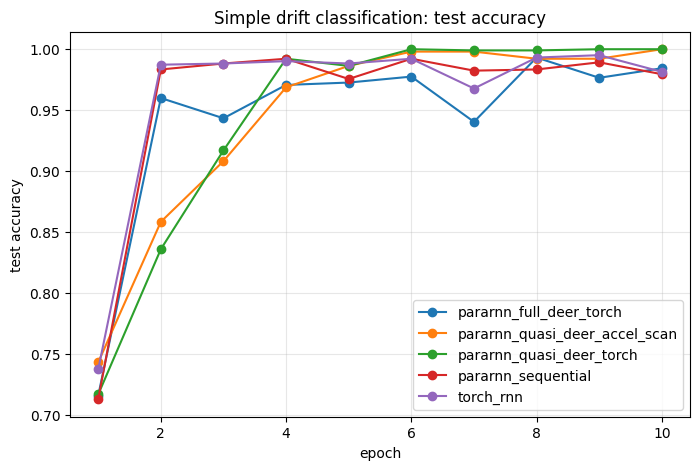

In [10]:
# Plot test accuracy.
plt.figure(figsize=(8, 5))
for name in sorted({row["model"] for row in all_history}):
    rows = [row for row in all_history if row["model"] == name]
    xs = [row["epoch"] for row in rows]
    ys = [row["test_acc"] for row in rows]
    plt.plot(xs, ys, marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.title("Simple drift classification: test accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

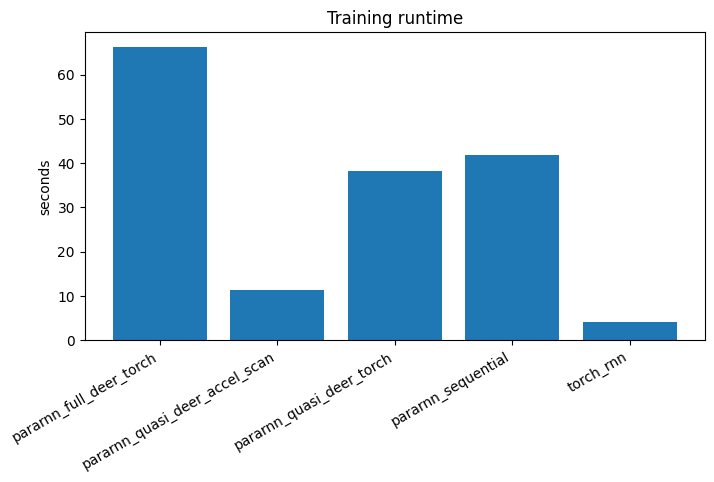

In [11]:
# Plot final runtime.
names = [row["model"] for row in final_rows]
times = [row["elapsed_sec"] for row in final_rows]

plt.figure(figsize=(8, 4))
plt.bar(names, times)
plt.ylabel("seconds")
plt.title("Training runtime")
plt.xticks(rotation=30, ha="right")
plt.show()

In [12]:
# Inspect DEER metadata for ParaRNN models.
for name, model in models.items():
    if hasattr(model, "rnn") and hasattr(model.rnn, "last_deer_infos"):
        infos = getattr(model.rnn, "last_deer_infos", None)
        if infos:
            print(f"\n{name}")
            for k, v in infos[0].items():
                if k in {
                    "num_iters",
                    "converged",
                    "final_error",
                    "quasi",
                    "scan_backend",
                    "jacobian_backend",
                    "linearization_backend",
                    "pararnn_deer_kind",
                    "cell_variant",
                }:
                    print(f"  {k}: {v}")


pararnn_full_deer_torch
  num_iters: 8
  scan_backend: torch
  quasi: False
  jacobian_backend: explicit_dense
  linearization_backend: custom_dense
  cell_variant: dense_vanilla_tanh

pararnn_quasi_deer_torch
  num_iters: 8
  scan_backend: torch
  quasi: True
  jacobian_backend: explicit_diag_from_dense
  linearization_backend: custom_diag_from_dense
  cell_variant: dense_vanilla_tanh_scalar_quasi
  pararnn_deer_kind: scalar_quasi

pararnn_quasi_deer_accel_scan
  num_iters: 8
  scan_backend: accel_scan
  quasi: True
  jacobian_backend: explicit_diag_from_dense
  linearization_backend: custom_diag_from_dense
  cell_variant: dense_vanilla_tanh_scalar_quasi
  pararnn_deer_kind: scalar_quasi


## Expected interpretation

For this simple task, all trainable variants should move well above chance.

The mathematically important distinction is:

$$
J_t = \mathrm{diag}(\phi'(u_t)) W_{hh}
$$

for full dense `ParaRNN`. Full-DEER uses this dense Jacobian. Quasi-DEER keeps only

$$
\mathrm{diag}(J_t)
$$

so it is an approximation. On this easy drift task, quasi-DEER should still often learn because the required recurrent computation is close to an accumulator and does not require complicated dense hidden-state mixing.
